# Weight Pruning — 4-Task Scaling Analysis

Compares **Block-Sparse** (oracle task-aligned) at a fixed budget against **Dense** at six
parameter budgets {1×, 2×, 4×, 8×, 16×, 32×} of the new 4-task base (~19 k weights = 6 dense
units = 24 block-sparse units).

For each setting (stationary `permute_period = 0`, non-stationary `permute_period = 4000`):

1. Step-size sensitivity for block-sparse (one budget).
2. Step-size sensitivity for dense, hue = hidden-unit count.
3. Asymptotic performance vs hidden-unit count, taking the best step-size for each size; the
   horizontal dotted line marks block-sparse asymptotic performance at its best step-size.

For the non-stationary case we also plot full learning curves for the best block-sparse run
and the best (size, step-size) dense run.

Loss is reported per task (`loss / n_tasks`). Non-stationary runs were trained without any
held-out test split, so all panels use training-pool metrics for consistency.


In [63]:
# import os
# os.environ['MLFLOW_TRACKING_URI'] = 'postgresql:///mlflow?host=/var/run/postgresql&port=5433'
# os.environ['OPTUNA_TRACKING_URI'] = 'postgresql:///optuna?host=/var/run/postgresql&port=5433'

# Run once to fetch from MLflow. Comment out after first run.
# from phd.research_utils.scripts.mlflow_download import download_experiment
# download_experiment('paper-weight-pruning-scaling-sweep', output_dir='data', include_seed_runs=True)

In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

set_matplotlib_style('default')
%matplotlib inline

# Block-sparse vs dense palette (only two methods here).
METHOD_ORDER = ['Dense', 'Block-Sparse']
METHOD_PALETTE = get_color_palette(classes=METHOD_ORDER)
# Sequential palette over dense hidden-unit counts.
HIDDEN_SIZES = [6, 12, 24, 48, 96, 192, 384]
SIZE_PALETTE = dict(zip(HIDDEN_SIZES, sns.color_palette('flare', n_colors=len(HIDDEN_SIZES))))
METHOD_PALETTE

SIZE_TO_MULT = {6: '1×', 12: '2×', 24: '4×', 48: '8×', 96: '16×', 192: '32×', 384: '64×'}


def relabel_size_axis():
    """Replace x-axis tick labels (hidden-unit counts) with budget multipliers."""
    ax = plt.gca()
    new_labels = []
    for t in ax.get_xticklabels():
        try:
            new_labels.append(SIZE_TO_MULT[int(float(t.get_text()))])
        except (ValueError, KeyError):
            new_labels.append(t.get_text())
    ax.set_xticklabels(new_labels)


## Resolve child sweep names

Per-seed child runs only carry a `mlflow.parentRunId` tag — their `sweep_name` falls back to
`'default'` in the download. Look up each child's parent and copy its `sweep_name` over.
The cache auto-invalidates when the params CSV is newer.

In [65]:
def resolve_default_sweep_names(params_path, experiment_name, cache_path):
    df = pd.read_csv(params_path, index_col=0)
    if (df['sweep_name'] == 'default').sum() == 0:
        return
    cache_stale = (
        not os.path.exists(cache_path)
        or os.path.getmtime(cache_path) < os.path.getmtime(params_path)
    )
    if cache_stale:
        import mlflow
        from mlflow.tracking import MlflowClient
        mlflow.set_tracking_uri(os.environ.get('MLFLOW_TRACKING_URI', 'sqlite:///mlruns.db'))
        client = MlflowClient()
        exp = client.get_experiment_by_name(experiment_name)
        all_runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=50000)
        sweep_by = {r.info.run_id: r.data.tags.get('sweep_name', 'default') for r in all_runs}
        rows = []
        for r in all_runs:
            pid = r.data.tags.get('mlflow.parentRunId')
            if pid:
                rows.append({'run_id': r.info.run_id, 'parent_sweep': sweep_by.get(pid, 'default')})
        pd.DataFrame(rows).to_csv(cache_path, index=False)
        print(f'Refreshed parent map: {cache_path} ({len(rows)} children)')

    map_df = pd.read_csv(cache_path)
    map_dict = dict(zip(map_df['run_id'], map_df['parent_sweep']))
    is_default = df['sweep_name'] == 'default'
    df.loc[is_default, 'sweep_name'] = df.loc[is_default, 'run_id'].map(map_dict).fillna('default')
    df.to_csv(params_path)
    print(f'Resolved {is_default.sum()} child rows in {params_path}')


resolve_default_sweep_names(
    'data/paper_weight_pruning_scaling_sweep_params.csv',
    'paper-weight-pruning-scaling-sweep',
    'data/sweep_parent_map.csv',
)


## Load data and helpers

In [66]:
sweep_cfg, sweep_run = load_experiment_data(
    'data/paper_weight_pruning_scaling_sweep_params.csv',
    'data/paper_weight_pruning_scaling_sweep_metrics.csv',
)


def drop_summary_rows(run_dfs):
    for k, rdf in run_dfs.items():
        mask = rdf['loss'].isna() & rdf['asymptotic_loss'].notna()
        run_dfs[k] = rdf[~mask].copy()


drop_summary_rows(sweep_run)
print('Sweep buckets:', {k: len(v) for k, v in sweep_cfg.items()})


Sweep buckets: {'02b_dense_4task_nonstationary_scaling_lr': 42, '01_dense_4task_scaling_lr': 252, '02b_block_sparse_4task_nonstationary_lr': 5, '02_dense_4task_nonstationary_scaling_lr': 36, '02_block_sparse_4task_nonstationary_lr': 5, '01_block_sparse_4task_lr': 30}


In [67]:
def add_method_col(cfg):
    cfg = cfg.copy()
    init = cfg.get('model.init_strategy', pd.Series('', index=cfg.index)).astype(str)
    method = pd.Series(index=cfg.index, dtype=object)
    method[init == 'dense'] = 'Dense'
    method[init == 'block_sparse'] = 'Block-Sparse'
    cfg['Method'] = method
    return cfg


def gather(cfg_dfs, run_dfs, sweep_pattern):
    """Pull parent rows for sweeps matching `sweep_pattern`.

    Each parent row is one trial whose metric history is already the mean
    across seeds (mlflow-sweeper logs it that way), so we don't need per-seed
    children and don't show error bars.
    """
    keys = [k for k in cfg_dfs if sweep_pattern(k)]
    if not keys:
        return pd.DataFrame(), pd.DataFrame()
    cfg = pd.concat([cfg_dfs[k] for k in keys], ignore_index=True)
    run = pd.concat([run_dfs[k] for k in keys], ignore_index=True)
    if 'child_seed' in cfg.columns:
        cfg = cfg[cfg['child_seed'].isna()].copy()
        run = run[run['run_id'].isin(cfg['run_id'])].copy()
    cfg = add_method_col(cfg)
    cfg = cfg[cfg['Method'].notna()].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    for col in ('optimizer.learning_rate', 'task.n_tasks', 'model.initial_hidden_units'):
        if col in cfg.columns:
            cfg[col] = pd.to_numeric(cfg[col], errors='coerce')
    nt_map = dict(zip(cfg['run_id'], cfg.get('task.n_tasks', pd.Series(1, index=cfg.index))))
    run['loss_per_task'] = run['loss'] / run['run_id'].map(nt_map).fillna(1.0)
    return cfg, run


def asymptotic_metric(cfg, run, metric_col, group_cols):
    """Mean over the last 5 % of training steps, aggregated per group."""
    max_step = run.groupby('run_id')['step'].max()
    thr = (max_step * 0.95).rename('_thr')
    rdf = run.merge(thr, left_on='run_id', right_index=True)
    last5 = rdf[rdf['step'] >= rdf['_thr']]
    per_run = last5.groupby('run_id')[metric_col].mean().dropna().rename('_metric')
    merged = cfg.merge(per_run, left_on='run_id', right_index=True)
    return merged.groupby(group_cols + ['optimizer.learning_rate'])['_metric'].mean().reset_index()


def filter_to_best(cfg, run, group_cols, metric_col, direction='min'):
    """Keep only the rows whose LR is best within each group.

    direction: 'min' (default) selects the LR with the lowest mean metric
    (e.g. loss); 'max' selects the highest (e.g. accuracy).
    """
    asym = asymptotic_metric(cfg, run, metric_col, group_cols)
    grouped = asym.groupby(group_cols)['_metric']
    idxs = grouped.idxmin() if direction == 'min' else grouped.idxmax()
    best = asym.loc[idxs]
    keep = set(map(tuple, best[group_cols + ['optimizer.learning_rate']].values))
    cfg_keys = list(map(tuple, cfg[group_cols + ['optimizer.learning_rate']].values))
    mask = pd.Series([k in keep for k in cfg_keys], index=cfg.index)
    return cfg[mask].copy(), run[run['run_id'].isin(cfg.loc[mask, 'run_id'])].copy(), best


---
## 1. Stationary  (`permute_period = 0`)  (sweep_name prefix `01_`)

In [68]:
sec_cfg, sec_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('01_') and k.endswith('_lr'),
)
bs_cfg = sec_cfg[sec_cfg['Method'] == 'Block-Sparse'].copy()
bs_run = sec_run[sec_run['run_id'].isin(bs_cfg['run_id'])].copy()
de_cfg = sec_cfg[sec_cfg['Method'] == 'Dense'].copy()
de_run = sec_run[sec_run['run_id'].isin(de_cfg['run_id'])].copy()
print(f'Block-Sparse rows: {len(bs_cfg)}  |  Dense rows: {len(de_cfg)} '
      f'({de_cfg["model.initial_hidden_units"].nunique()} sizes × '
      f'{de_cfg["optimizer.learning_rate"].nunique()} step-sizes)')


Block-Sparse rows: 5  |  Dense rows: 42 (7 sizes × 6 step-sizes)


### Block-sparse: step-size sensitivity

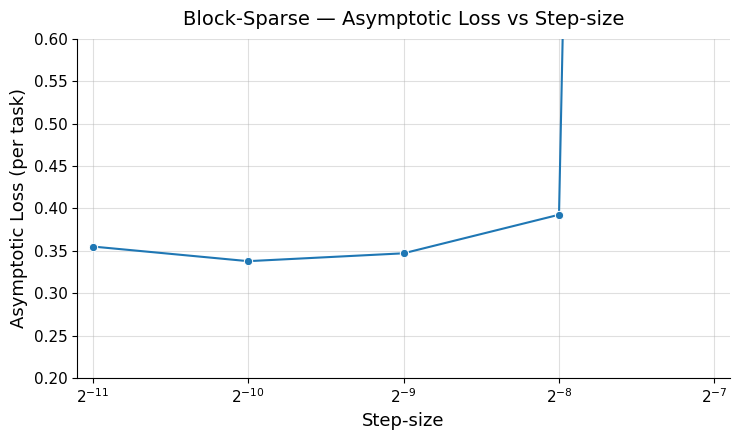

In [69]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_run, config_df=bs_cfg,
    x_col='optimizer.learning_rate',
    title='Block-Sparse — Asymptotic Loss vs Step-size',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.2, 0.6)
plt.tight_layout(); plt.show()


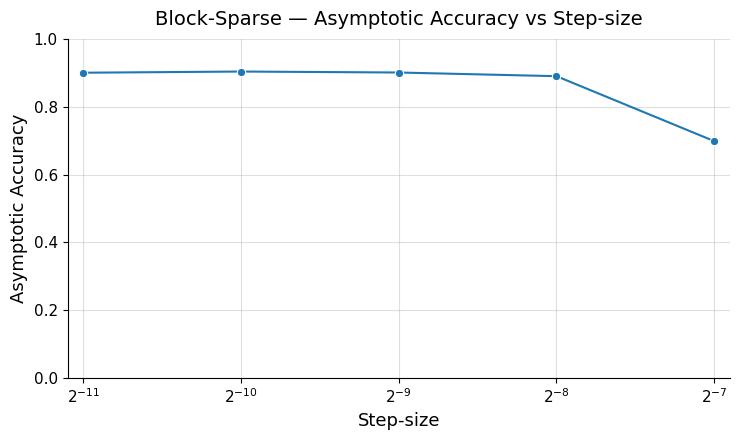

In [70]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_run, config_df=bs_cfg,
    x_col='optimizer.learning_rate',
    title='Block-Sparse — Asymptotic Accuracy vs Step-size',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout(); plt.show()


### Dense: step-size sensitivity (hue = hidden units)

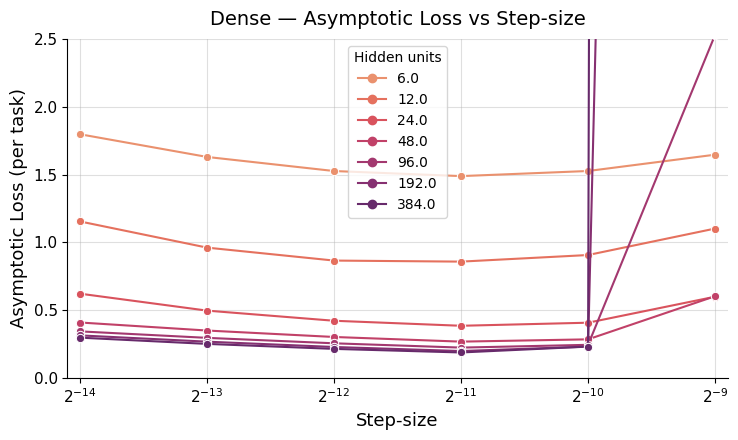

In [71]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_run, config_df=de_cfg,
    x_col='optimizer.learning_rate',
    title='Dense — Asymptotic Loss vs Step-size',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    hue_col='model.initial_hidden_units', legend_title='Hidden units',
    palette=SIZE_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 2.5)
plt.tight_layout(); plt.show()


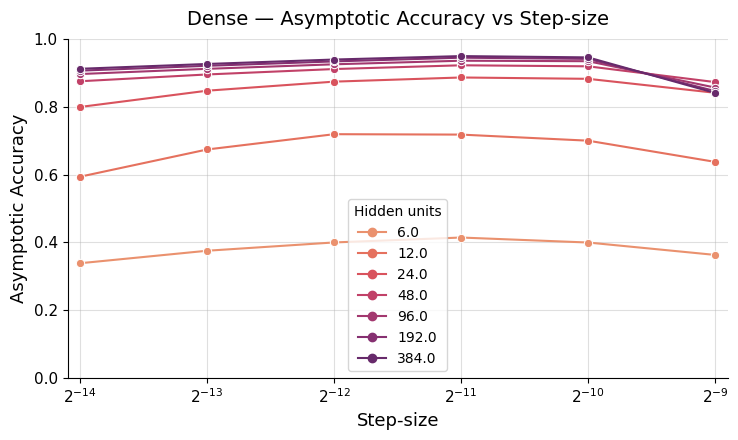

In [72]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_run, config_df=de_cfg,
    x_col='optimizer.learning_rate',
    title='Dense — Asymptotic Accuracy vs Step-size',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    hue_col='model.initial_hidden_units', legend_title='Hidden units',
    palette=SIZE_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout(); plt.show()


### Asymptotic performance vs model size (best step-size per size)

The dotted horizontal line marks the asymptotic block-sparse performance at its best
step-size — a fixed-budget reference for the dense scaling curve.

In [73]:
# Best LR per dense size, on each metric.
de_best_loss_cfg, de_best_loss_run, de_best_loss = filter_to_best(
    de_cfg, de_run, group_cols=['model.initial_hidden_units'], metric_col='loss_per_task',
)
de_best_acc_cfg,  de_best_acc_run,  de_best_acc  = filter_to_best(
    de_cfg, de_run, group_cols=['model.initial_hidden_units'], metric_col='accuracy',
    direction='max',
)

# Block-sparse asymptotic at its best LR (single value per metric).
bs_asym_loss = asymptotic_metric(bs_cfg, bs_run, 'loss_per_task', group_cols=[])
bs_best_loss_value = bs_asym_loss['_metric'].min()
bs_best_loss_lr = bs_asym_loss.loc[bs_asym_loss['_metric'].idxmin(), 'optimizer.learning_rate']

bs_asym_acc = asymptotic_metric(bs_cfg, bs_run, 'accuracy', group_cols=[])
bs_best_acc_value = bs_asym_acc['_metric'].max()
bs_best_acc_lr = bs_asym_acc.loc[bs_asym_acc['_metric'].idxmax(), 'optimizer.learning_rate']

print(f'Block-Sparse best step-size (loss):     2^{int(np.log2(bs_best_loss_lr)):d}  '
      f'-> asymptotic loss/task = {bs_best_loss_value:.4f}')
print(f'Block-Sparse best step-size (accuracy): 2^{int(np.log2(bs_best_acc_lr)):d}  '
      f'-> asymptotic accuracy = {bs_best_acc_value:.4f}')
print()
print('Dense per-size best step-size (loss):')
print(de_best_loss[['model.initial_hidden_units', 'optimizer.learning_rate', '_metric']]
      .to_string(index=False))


Block-Sparse best step-size (loss):     2^-10  -> asymptotic loss/task = 0.3378
Block-Sparse best step-size (accuracy): 2^-10  -> asymptotic accuracy = 0.9037

Dense per-size best step-size (loss):
 model.initial_hidden_units  optimizer.learning_rate  _metric
                        6.0                 0.000488 1.488455
                       12.0                 0.000488 0.858100
                       24.0                 0.000488 0.385140
                       48.0                 0.000488 0.268256
                       96.0                 0.000488 0.224221
                      192.0                 0.000488 0.198846
                      384.0                 0.000488 0.188430


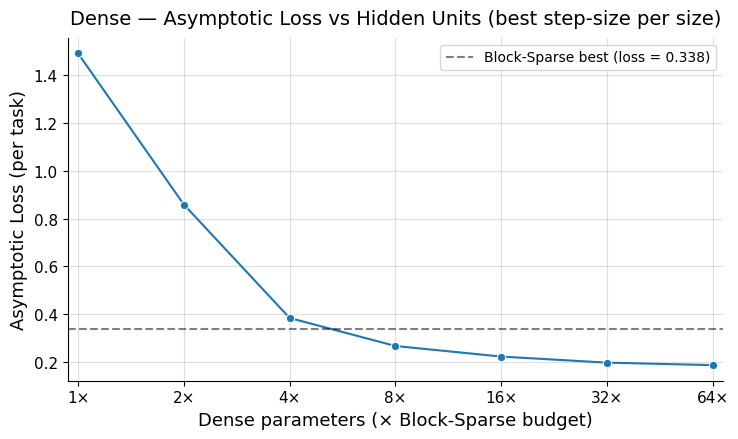

In [74]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_loss_run, config_df=de_best_loss_cfg,
    x_col='model.initial_hidden_units',
    title='Dense — Asymptotic Loss vs Hidden Units (best step-size per size)',
    x_label='Dense parameters (× Block-Sparse budget)', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    nan_policy='omit',
)
plt.axhline(bs_best_loss_value, linestyle='--', alpha=0.5, color='black',
            label=f'Block-Sparse best (loss = {bs_best_loss_value:.3f})')
relabel_size_axis()
plt.legend()
plt.tight_layout(); plt.show()


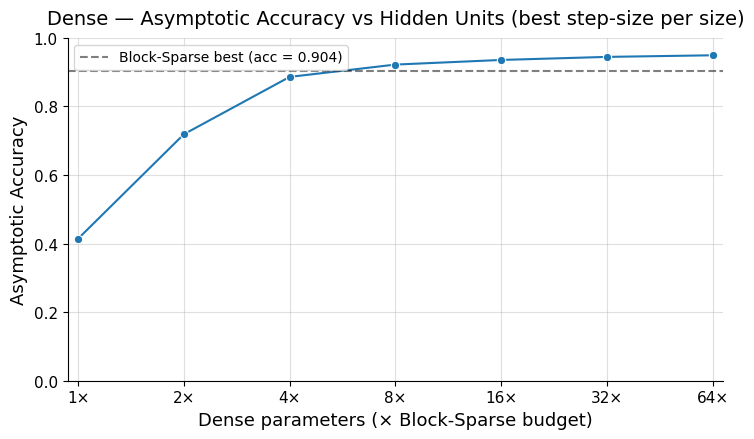

In [75]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_acc_run, config_df=de_best_acc_cfg,
    x_col='model.initial_hidden_units',
    title='Dense — Asymptotic Accuracy vs Hidden Units (best step-size per size)',
    x_label='Dense parameters (× Block-Sparse budget)', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    nan_policy='omit',
)
plt.axhline(bs_best_acc_value, linestyle='--', alpha=0.5, color='black',
            label=f'Block-Sparse best (acc = {bs_best_acc_value:.3f})')
plt.ylim(0.0, 1.0)
relabel_size_axis()
plt.legend()
plt.tight_layout(); plt.show()


---
## 2. Non-Stationary  (`permute_period = 4000`)  (sweep_name prefix `02_`)

In [76]:
sec_cfg, sec_run = gather(
    sweep_cfg, sweep_run,
    sweep_pattern=lambda k: k.startswith('02b_') and k.endswith('_lr'),
)
bs_cfg = sec_cfg[sec_cfg['Method'] == 'Block-Sparse'].copy()
bs_run = sec_run[sec_run['run_id'].isin(bs_cfg['run_id'])].copy()
de_cfg = sec_cfg[sec_cfg['Method'] == 'Dense'].copy()
de_run = sec_run[sec_run['run_id'].isin(de_cfg['run_id'])].copy()
print(f'Block-Sparse rows: {len(bs_cfg)}  |  Dense rows: {len(de_cfg)} '
      f'({de_cfg["model.initial_hidden_units"].nunique()} sizes × '
      f'{de_cfg["optimizer.learning_rate"].nunique()} step-sizes)')


Block-Sparse rows: 5  |  Dense rows: 42 (7 sizes × 6 step-sizes)


### Block-sparse: step-size sensitivity

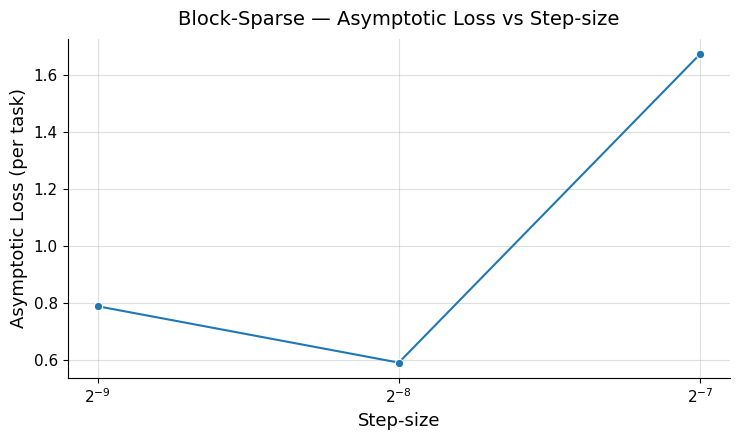

In [77]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_run, config_df=bs_cfg,
    x_col='optimizer.learning_rate',
    title='Block-Sparse — Asymptotic Loss vs Step-size',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    pow_2_x_axis=True, nan_policy='omit',
)
plt.tight_layout(); plt.show()


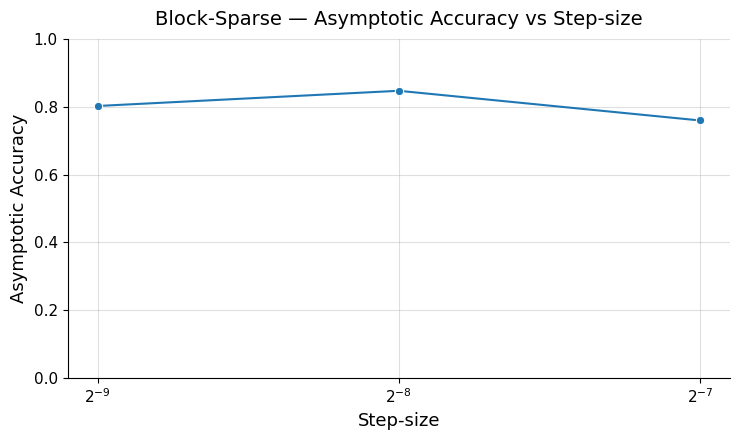

In [78]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=bs_run, config_df=bs_cfg,
    x_col='optimizer.learning_rate',
    title='Block-Sparse — Asymptotic Accuracy vs Step-size',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout(); plt.show()


### Dense: step-size sensitivity (hue = hidden units)

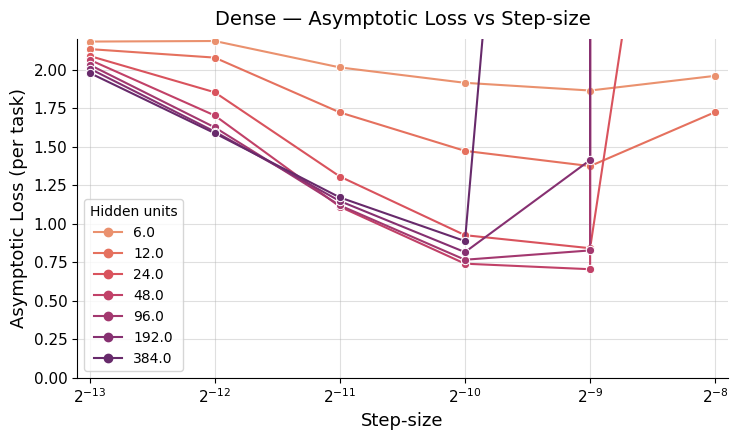

In [79]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_run, config_df=de_cfg,
    x_col='optimizer.learning_rate',
    title='Dense — Asymptotic Loss vs Step-size',
    x_label='Step-size', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    hue_col='model.initial_hidden_units', legend_title='Hidden units',
    palette=SIZE_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 2.2)
plt.tight_layout(); plt.show()


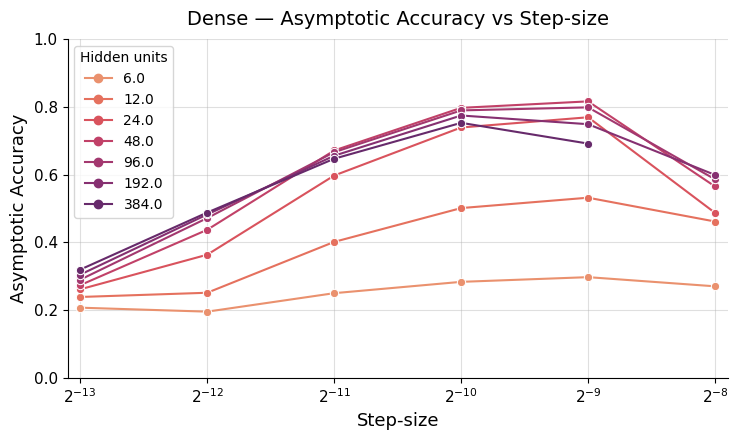

In [80]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_run, config_df=de_cfg,
    x_col='optimizer.learning_rate',
    title='Dense — Asymptotic Accuracy vs Step-size',
    x_label='Step-size', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    hue_col='model.initial_hidden_units', legend_title='Hidden units',
    palette=SIZE_PALETTE,
    pow_2_x_axis=True, nan_policy='omit',
)
plt.ylim(0.0, 1.0)
plt.tight_layout(); plt.show()


### Asymptotic performance vs model size (best step-size per size)

The dotted horizontal line marks the asymptotic block-sparse performance at its best
step-size — a fixed-budget reference for the dense scaling curve.

In [81]:
# Best LR per dense size, on each metric.
de_best_loss_cfg, de_best_loss_run, de_best_loss = filter_to_best(
    de_cfg, de_run, group_cols=['model.initial_hidden_units'], metric_col='loss_per_task',
)
de_best_acc_cfg,  de_best_acc_run,  de_best_acc  = filter_to_best(
    de_cfg, de_run, group_cols=['model.initial_hidden_units'], metric_col='accuracy',
    direction='max',
)

# Block-sparse asymptotic at its best LR (single value per metric).
bs_asym_loss = asymptotic_metric(bs_cfg, bs_run, 'loss_per_task', group_cols=[])
bs_best_loss_value = bs_asym_loss['_metric'].min()
bs_best_loss_lr = bs_asym_loss.loc[bs_asym_loss['_metric'].idxmin(), 'optimizer.learning_rate']

bs_asym_acc = asymptotic_metric(bs_cfg, bs_run, 'accuracy', group_cols=[])
bs_best_acc_value = bs_asym_acc['_metric'].max()
bs_best_acc_lr = bs_asym_acc.loc[bs_asym_acc['_metric'].idxmax(), 'optimizer.learning_rate']

print(f'Block-Sparse best step-size (loss):     2^{int(np.log2(bs_best_loss_lr)):d}  '
      f'-> asymptotic loss/task = {bs_best_loss_value:.4f}')
print(f'Block-Sparse best step-size (accuracy): 2^{int(np.log2(bs_best_acc_lr)):d}  '
      f'-> asymptotic accuracy = {bs_best_acc_value:.4f}')
print()
print('Dense per-size best step-size (loss):')
print(de_best_loss[['model.initial_hidden_units', 'optimizer.learning_rate', '_metric']]
      .to_string(index=False))


Block-Sparse best step-size (loss):     2^-8  -> asymptotic loss/task = 0.5902
Block-Sparse best step-size (accuracy): 2^-8  -> asymptotic accuracy = 0.8470

Dense per-size best step-size (loss):
 model.initial_hidden_units  optimizer.learning_rate  _metric
                        6.0                 0.001953 1.865044
                       12.0                 0.001953 1.374765
                       24.0                 0.001953 0.842114
                       48.0                 0.001953 0.705836
                       96.0                 0.000977 0.767364
                      192.0                 0.000977 0.816597
                      384.0                 0.000977 0.888417


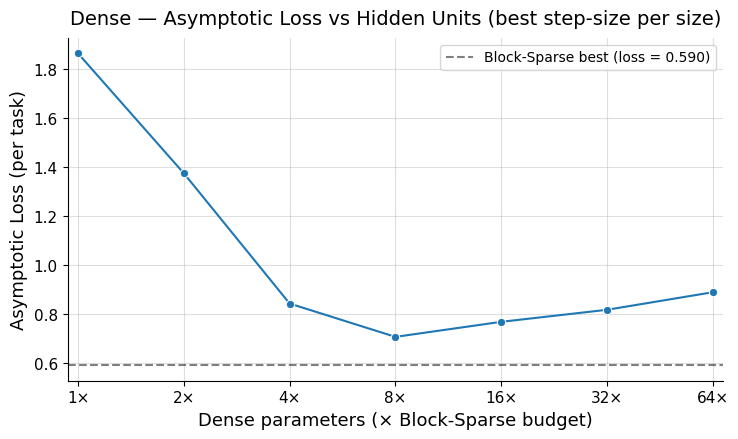

In [82]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_loss_run, config_df=de_best_loss_cfg,
    x_col='model.initial_hidden_units',
    title='Dense — Asymptotic Loss vs Hidden Units (best step-size per size)',
    x_label='Dense parameters (× Block-Sparse budget)', y_label='Asymptotic Loss (per task)',
    metric_col='loss_per_task', metric_type='final_avg',
    nan_policy='omit',
)
plt.axhline(bs_best_loss_value, linestyle='--', alpha=0.5, color='black',
            label=f'Block-Sparse best (loss = {bs_best_loss_value:.3f})')
relabel_size_axis()
plt.legend()
plt.tight_layout(); plt.show()


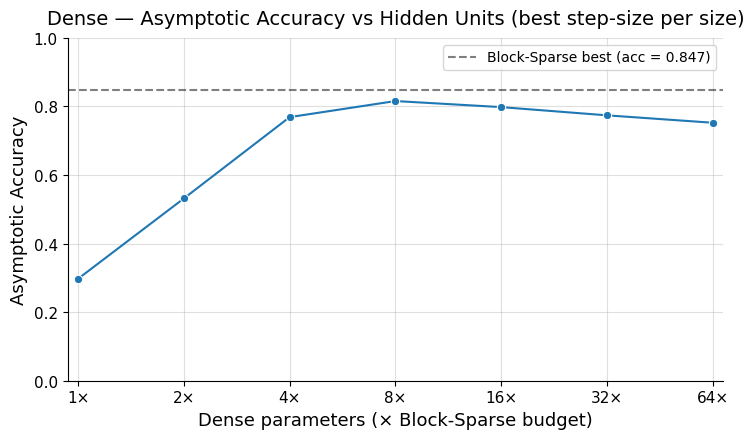

In [83]:
plt.figure(figsize=(7.5, 4.5))
plot_param_sensitivity(
    run_df=de_best_acc_run, config_df=de_best_acc_cfg,
    x_col='model.initial_hidden_units',
    title='Dense — Asymptotic Accuracy vs Hidden Units (best step-size per size)',
    x_label='Dense parameters (× Block-Sparse budget)', y_label='Asymptotic Accuracy',
    metric_col='accuracy', metric_type='final_avg',
    nan_policy='omit',
)
plt.axhline(bs_best_acc_value, linestyle='--', alpha=0.5, color='black',
            label=f'Block-Sparse best (acc = {bs_best_acc_value:.3f})')
plt.ylim(0.0, 1.0)
relabel_size_axis()
plt.legend()
plt.tight_layout(); plt.show()


### Best-config learning curves

Block-Sparse at its best step-size, vs Dense at its best (size, step-size) combo.

In [84]:
# Best dense (size, lr) by loss.
de_loss_pair = de_best_loss.loc[de_best_loss['_metric'].idxmin()]
de_best_size = int(de_loss_pair['model.initial_hidden_units'])
de_best_lr = float(de_loss_pair['optimizer.learning_rate'])
print(f'Best Dense (loss): {de_best_size} hidden units @ '
      f'2^{int(np.log2(de_best_lr)):d} -> loss/task = {de_loss_pair["_metric"]:.4f}')

bs_keep = bs_cfg[np.isclose(bs_cfg['optimizer.learning_rate'], bs_best_loss_lr)]
de_keep = de_cfg[
    (de_cfg['model.initial_hidden_units'] == de_best_size)
    & np.isclose(de_cfg['optimizer.learning_rate'], de_best_lr)
]
keep_cfg = pd.concat([bs_keep, de_keep], ignore_index=True)
keep_run = sec_run[sec_run['run_id'].isin(keep_cfg['run_id'])].copy()
print(f'Combined per-seed runs for learning curves: {len(keep_cfg)} '
      f'({len(bs_keep)} block-sparse + {len(de_keep)} dense)')


Best Dense (loss): 48 hidden units @ 2^-9 -> loss/task = 0.7058
Combined per-seed runs for learning curves: 2 (1 block-sparse + 1 dense)


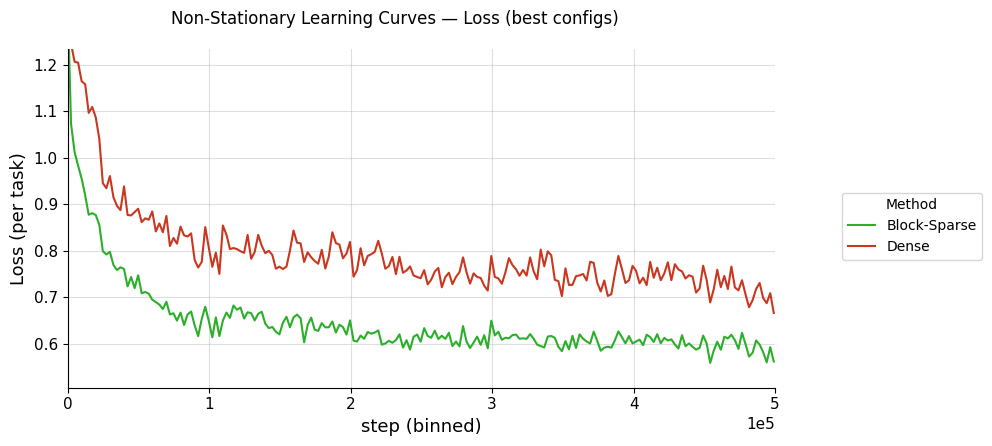

In [85]:
plot_learning_curves(
    run_df=keep_run, config_df=keep_cfg,
    n_bins=200, figsize=(8, 4.5),
    y_col='loss_per_task', y_label='Loss (per task)',
    hue_col='Method', legend_title='Method', palette=METHOD_PALETTE,
)
plt.suptitle('Non-Stationary Learning Curves — Loss (best configs)')
plt.tight_layout(); plt.show()


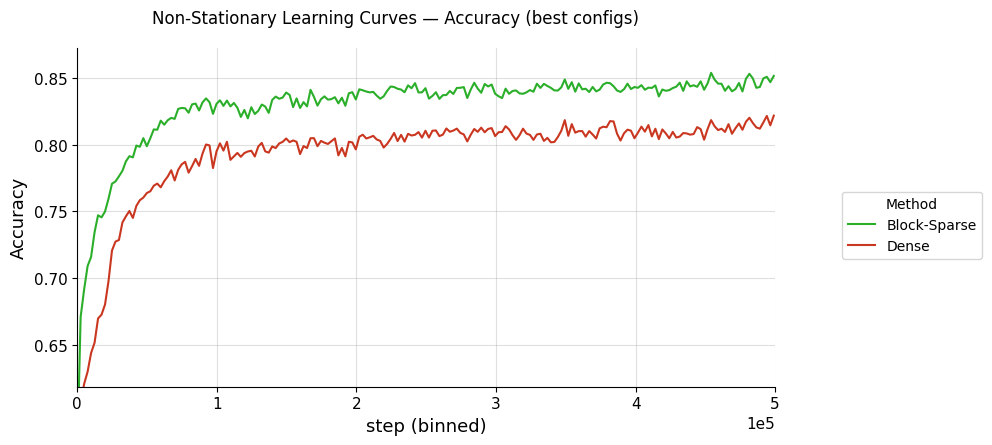

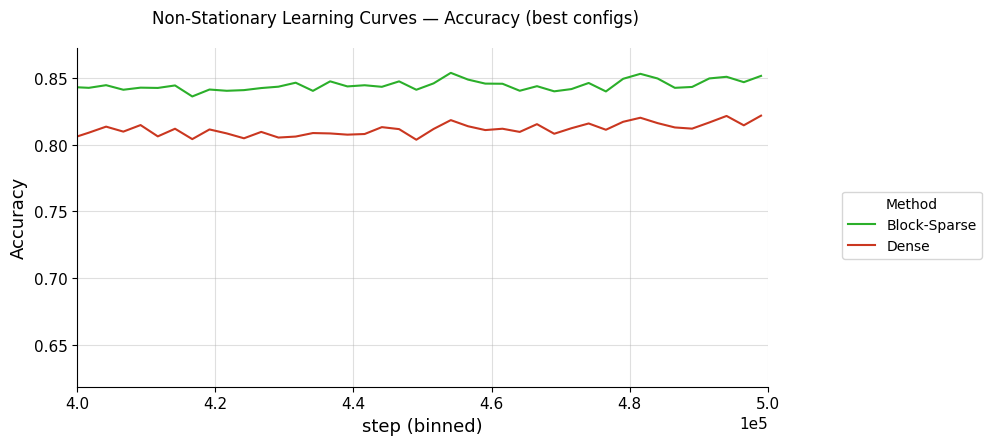

In [86]:
plot_learning_curves(
    run_df=keep_run, config_df=keep_cfg,
    n_bins=200, figsize=(8, 4.5),
    y_col='accuracy', y_label='Accuracy',
    hue_col='Method', legend_title='Method', palette=METHOD_PALETTE,
)
plt.suptitle('Non-Stationary Learning Curves — Accuracy (best configs)')
plt.tight_layout(); plt.show()

plot_learning_curves(
    run_df=keep_run, config_df=keep_cfg,
    figsize=(8, 4.5),
    y_col='accuracy', y_label='Accuracy',
    hue_col='Method', legend_title='Method', palette=METHOD_PALETTE,
)
plt.suptitle('Non-Stationary Learning Curves — Accuracy (best configs)')
plt.xlim(400_000, 500_000)
plt.tight_layout(); plt.show()
